# Python Review: Functions, Classes, Vectorisation and Data Loading/Plotting

**Contents**
1. Functions
2. Classes
3. Vectorisation
4. Creating, saving, loading and plotting data

Cells marked **Example** can simply be run. Cells marked **Exercise** contain `# TODO` gaps for you to complete.

## 0. Setup

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## 1. Functions

### Example 1.1: Mean squared error

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In [3]:
def mean_squared_error(y_true, y_pred):
    """Return the mean squared error between two sequences of equal length."""
    n = len(y_true)
    total = 0.0
    for i in range(n):
        total += (y_true[i] - y_pred[i]) ** 2
    return total / n

In [4]:
y_true = [3.0, -0.5, 2.0, 7.0]
y_pred = [2.5,  0.0, 2.0, 8.0]

print("MSE:", mean_squared_error(y_true, y_pred))

MSE: 0.375


### Exercise 1: Mean absolute error

Complete the function below.

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

In [5]:
def mean_absolute_error(y_true, y_pred):
    """Return the mean absolute error between two sequences of equal length."""
    # TODO: compute and return the MAE (hint: abs())
    return sum(abs(y_true[i] - y_pred[i]) for i in range(len(y_true))) / len(y_true)

In [6]:
# Check your answer (should print True)
print(np.isclose(mean_absolute_error(y_true, y_pred), 0.5))

True


---
## 2. Classes

### Example 2.0

In [13]:
# a class is like a template for an object, 
# so Cat here creates a template for cats, 
# and then we can create specific cats from that template, like Tyson and Lily below

class Cat:
    fur = "fluffy" # attributes shared by all instances of the class - all cats have fluffy fur
    
    def __init__(self, name, age): # __init__ always runs when you call a class, and defines the attributes of the object - here, we define the name and the age of the specific cat objects we create (Tyson and Lily)
        self.name = name # self refers to the specific instance of the class, or the "object", so tyson or lily below
        self.age = age

    def food(self, mood="happy"):
        if mood == "happy": # an optional argument with a default value, so if we don't pass in a mood, it will default to "happy"
            if self.age < 5:
                return "I like to eat kitten food."
            else:
                return "I like to eat fish."
        else:
            return "I don't feel like eating right now."

In [14]:
tyson = Cat("Tyson", 12)

lily = Cat("Lily", 3)

print(tyson.name)
print(lily.age)
print(lily.fur)

Tyson
3
fluffy


### Example 2.1: A simple linear model $\hat{y} = wx + b$

In [16]:
class LinearModel:
    """A one-dimensional linear model y = w * x + b."""

    def __init__(self, w, b):
        self.w = w
        self.b = b

    def predict(self, x):
        return [self.w * xi + self.b for xi in x]

    def score(self, x, y):
        """Return the MSE of the model's predictions."""
        return mean_squared_error(y, self.predict(x))

In [17]:
model = LinearModel(w=2.0, b=1.0)

x = [0.0, 1.0, 2.0, 3.0]
y = [1.1, 2.9, 5.2, 6.8]

print("Predictions:", model.predict(x))
print("MSE:        ", model.score(x, y))

Predictions: [1.0, 3.0, 5.0, 7.0]
MSE:         0.025000000000000043


### Exercise 2: A standard scaler

Complete the class so that `transform` returns $z = (x - \mu) / \sigma$, where $\mu$ and $\sigma$ are learned in `fit`.

In [18]:
class StandardScaler:
    """Standardise data to have zero mean and unit standard deviation."""

    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, x):
        x = np.asarray(x)
        self.mean = np.mean(x)
        self.std = np.std(x)
        return self

    def transform(self, x):
        x = np.asarray(x)
        # TODO: return the standardised values
        return (x - self.mean) / self.std if self.std != 0 else x - self.mean

In [19]:
# Check your answer (should print True True)
scaler = StandardScaler().fit([2.0, 4.0, 6.0, 8.0])
z = scaler.transform([2.0, 4.0, 6.0, 8.0])
print(np.isclose(z.mean(), 0.0), np.isclose(z.std(), 1.0))

True True


---
## 3. Vectorisation

### Example 3.1: Timing the dot product

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_i b_i$$

In [20]:
def dot_loop(a, b):
    total = 0.0
    for i in range(len(a)):
        total += a[i] * b[i]
    return total

In [21]:
rng = np.random.default_rng(seed=0)
n = 1_000_000
a = rng.standard_normal(n)
b = rng.standard_normal(n)

start = time.perf_counter()
result_loop = dot_loop(a, b)
t_loop = time.perf_counter() - start

start = time.perf_counter()
result_vec = np.dot(a, b)
t_vec = time.perf_counter() - start

print(f"Loop:       {result_loop:.4f}  ({t_loop:.4f} s)")
print(f"Vectorised: {result_vec:.4f}  ({t_vec:.4f} s)")
print(f"Speed-up:   {t_loop / t_vec:.0f}x")

Loop:       -204.3492  (0.1811 s)
Vectorised: -204.3492  (0.9136 s)
Speed-up:   0x


### Exercise 3: Vectorised MSE

Write a vectorised version of `mean_squared_error` (no loops), then time it against the loop version from Section 1.

In [22]:
def mean_squared_error_vec(y_true, y_pred):
    """Vectorised mean squared error using NumPy."""
    return np.mean((y_true - y_pred) ** 2)

In [25]:
y_true = rng.standard_normal(n)
y_pred = rng.standard_normal(n)

# TODO: time mean_squared_error(y_true, y_pred) and store the time in t_loop
t_loop = 0

# TODO: time mean_squared_error_vec(y_true, y_pred) and store the time in t_vec
t_vec = 0

print(f"Loop:       {t_loop:.4f} s")
print(f"Vectorised: {t_vec:.4f} s")
print("Results match:", np.isclose(mean_squared_error(y_true, y_pred),
                                  mean_squared_error_vec(y_true, y_pred)))

Loop:       0.0000 s
Vectorised: 0.0000 s
Results match: True


---
## 4. Creating, Saving, Loading and Plotting Data

### Example 4.1: Create a dataset with the following relationship (epsilon is like adding noise)

$$y = 3x_1 - 2x_2 + 0.5x_3 + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 0.5^2)$$

In [29]:
rng = np.random.default_rng(seed=42)
n_samples = 200

x1 = rng.uniform(0, 1, n_samples)
x2 = rng.uniform(0, 1, n_samples)
x3 = rng.normal(0, 1, n_samples)
x4 = rng.normal(0, 1, n_samples)
noise = rng.normal(0, 0.5, n_samples)

y = 3 * x1 - 2 * x2 + 0.5 * x3 + noise



### Example 4.2: Save as CSV

In [30]:
data = np.column_stack([x1, x2, x3, x4, y])

np.savetxt("data.csv", data, delimiter=",", header="x1,x2,x3,x4,y", comments="")
print("Saved array of shape", data.shape)

Saved array of shape (200, 5)


### Example 4.3: Load with pandas

In [4]:
df = pd.read_csv("data.csv")
df.head()

,x1,x2,x3,x4,y
0,0.773956,0.777405,0.439637,-1.176615,1.008983
1,0.438878,0.971826,0.524188,-0.837463,-0.466381
2,0.858598,0.500741,0.276274,0.235448,1.171235
3,0.697368,0.143898,-1.412766,1.611116,1.022400
4,0.094177,0.013936,-2.310103,-1.222374,-1.273441


In [5]:
df.describe()

,x1,x2,x3,x4,y
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.493870,0.499223,-0.052466,-0.049941,0.424911
std,0.282312,0.288395,0.997321,1.037039,1.324981
min,0.007362,0.012303,-2.964529,-2.564744,-2.728636
25%,0.252216,0.236724,-0.708375,-0.845359,-0.590988
50%,0.479004,0.505428,-0.041323,-0.000320,0.507701
75%,0.747244,0.766523,0.550454,0.637586,1.442203
max,0.992376,0.986632,2.597674,2.549328,3.835900


### Example 4.4: Plot $x_1$ vs $y$

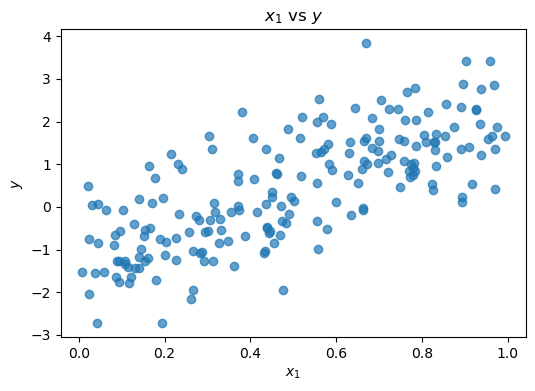

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["x1"], df["y"], alpha=0.7)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$y$")
ax.set_title("$x_1$ vs $y$")
plt.show()

### Exercise 4: Explore all features

1. Plot each feature ($x_1, \dots, x_4$) against $y$ on a 2 × 2 grid of subplots.
2. Print the correlation of each feature with $y$.

Which feature appears to have no relationship with $y$?

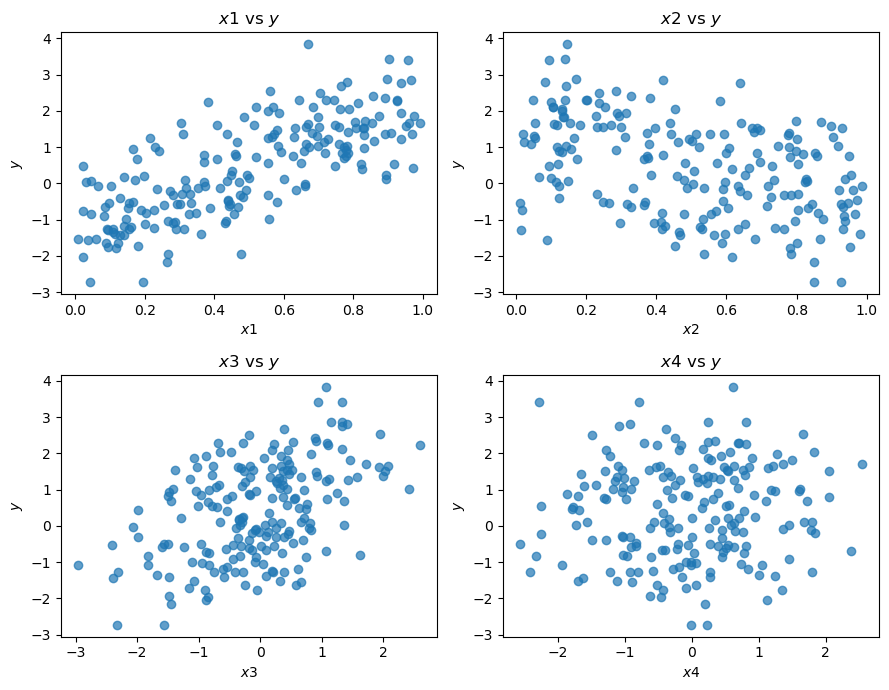

In [7]:
features = ["x1", "x2", "x3", "x4"]

fig, axes = plt.subplots(2, 2, figsize=(9, 7))

for ax, feature in zip(axes.flat, features):
    ax.scatter(df[feature], df["y"], alpha=0.7)
    ax.set_xlabel(f"${feature}$")
    ax.set_ylabel("$y$")
    ax.set_title(f"${feature}$ vs $y$")

plt.tight_layout()
plt.show()

In [9]:
# TODO: print the correlation of each feature with y (hint: df.corr())
print(df.corr()["y"])

x1    0.743813
x2   -0.429579
x3    0.467250
x4    0.055863
y     1.000000
Name: y, dtype: float64


### Technical - load the data file responses_week1_real.csv and visualise the data 
##### - is the data complete?
##### - what type of data is present? How do you process different types?
##### - which are the most useful data to show? 
##### - plots or tables?
##### - interesting combinations of the data?

In [10]:
real_csv = pd.read_csv("responses_week1_real.csv")

real_csv.head()

,id,code,qualification,alevel_subjects,reason,job,sector,enjoy,prior_programming,conf_maths,conf_programming,conf_python,career_clarity,postgrad,comments
0,2,659874,"International qualifications (IB, Baccalaureat...",Computer Science;Further Maths;Business Studie...,Job prospects and salary,Data science / data analysis,Startups / small companies,Finding patterns in data,Moderate (personal projects),5,4,4,5,Maybe,"I am interested in Additive Manufacturing, and..."
1,3,NaN,A-levels,Maths;Computer Science;English (Language or Li...,Job prospects and salary,Something outside tech,Finance,Building practical things that work (including...,Moderate (personal projects),3,3,3,2,Maybe,NaN
2,4,970507,"International qualifications (IB, Baccalaureat...",NaN,Job prospects and salary,"Product, project management or consulting",Not sure,Finding patterns in data,"A little (tutorials, school projects)",3,2,3,3,Maybe,NaN
3,5,061206,"International qualifications (IB, Baccalaureat...",NaN,I enjoyed programming before university,"Product, project management or consulting",Not sure,Building practical things that work (including...,Moderate (personal projects),2,4,3,2,Maybe,NaN
4,6,031097,A-levels,Maths;Chemistry;Biology;,Job prospects and salary,"Product, project management or consulting",Not sure,Finding patterns in data,"A little (tutorials, school projects)",4,3,3,2,Maybe,NaN


In [12]:
real_csv.isnull().sum()

id                    0
code                  4
qualification         0
alevel_subjects       5
reason                0
job                   0
sector                0
enjoy                 0
prior_programming     1
conf_maths            0
conf_programming      0
conf_python           0
career_clarity        0
postgrad              0
comments             29
dtype: int64

In [14]:
real_csv.shape

(37, 15)

We need to find out why the 5 people didnt choose an a level subject 

In [18]:
real_csv_no_a_level = real_csv[real_csv["alevel_subjects"].isnull()]

real_csv_no_a_level

,id,code,qualification,alevel_subjects,reason,job,sector,enjoy,prior_programming,conf_maths,conf_programming,conf_python,career_clarity,postgrad,comments
2,4,970507,"International qualifications (IB, Baccalaureat...",NaN,Job prospects and salary,"Product, project management or consulting",Not sure,Finding patterns in data,"A little (tutorials, school projects)",3,2,3,3,Maybe,NaN
3,5,061206,"International qualifications (IB, Baccalaureat...",NaN,I enjoyed programming before university,"Product, project management or consulting",Not sure,Building practical things that work (including...,Moderate (personal projects),2,4,3,2,Maybe,NaN
5,7,121212,"International qualifications (IB, Baccalaureat...",NaN,Genuine interest in AI/ML,Data science / data analysis,Startups / small companies,Building practical things that work (including...,"A little (tutorials, school projects)",4,3,3,3,Yes,NaN
23,25,NaN,Access course / foundation year,NaN,"Recommended by family, teachers or friends",Something outside tech,Startups / small companies,Building practical things that work (including...,NaN,3,3,3,4,No,I would like the module to discuss the potenti...
25,27,000422,"International qualifications (IB, Baccalaureat...",NaN,It was my insurance/clearing choice,Not sure yet,Startups / small companies,Working with people and coordinating,"A little (tutorials, school projects)",4,3,2,2,Maybe,NaN


## I want to see how "common" each response is 

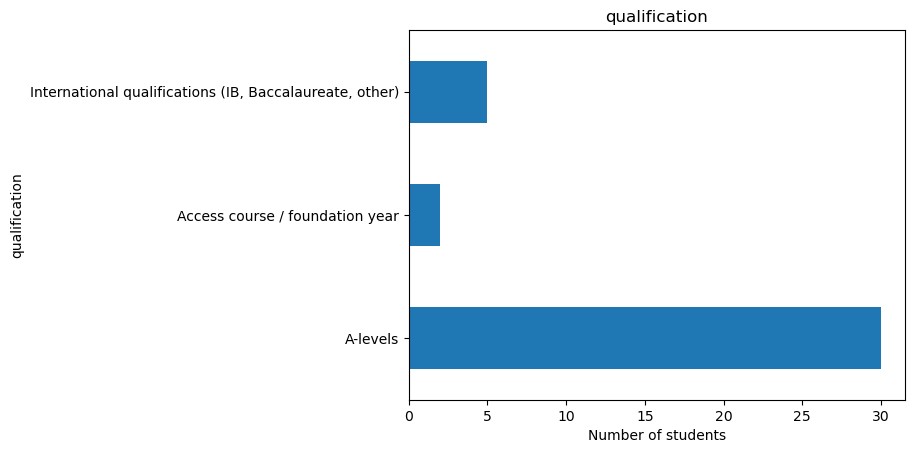

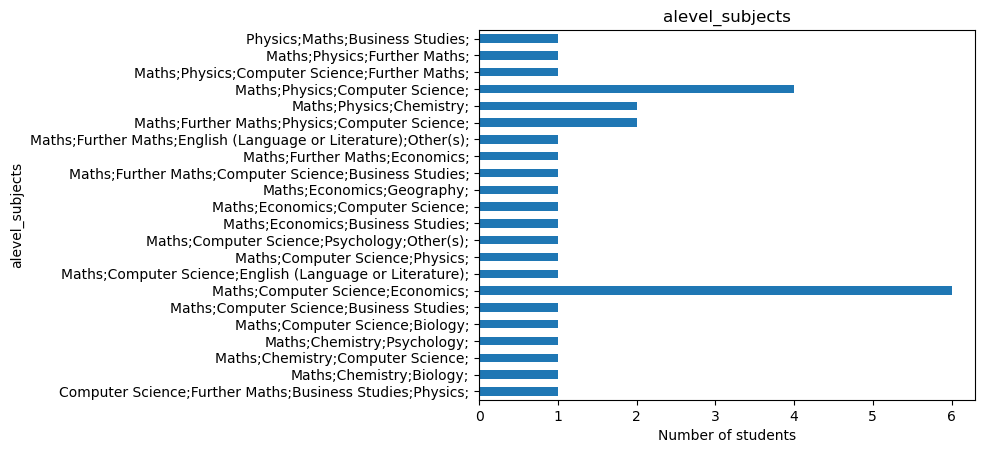

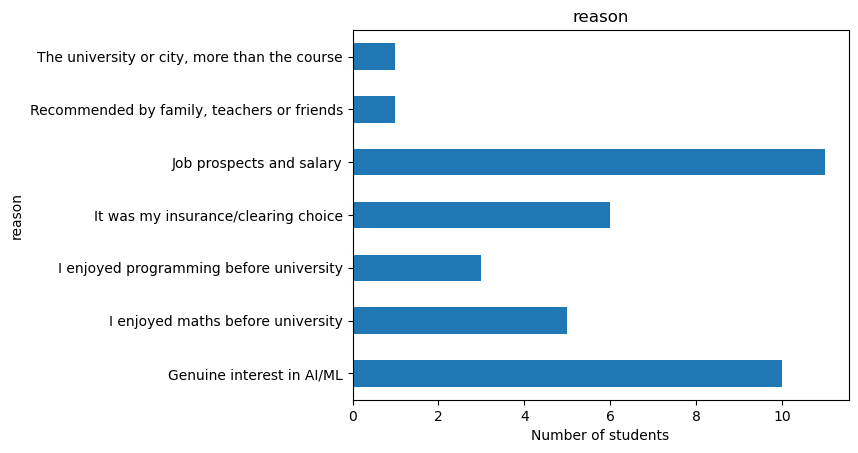

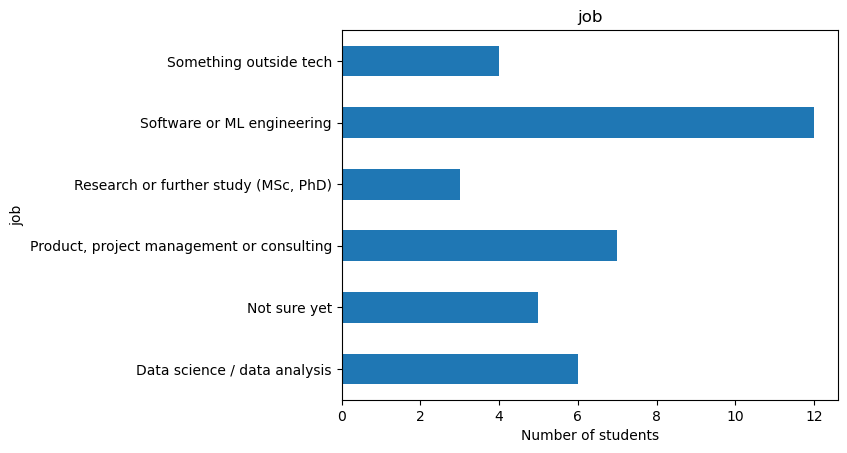

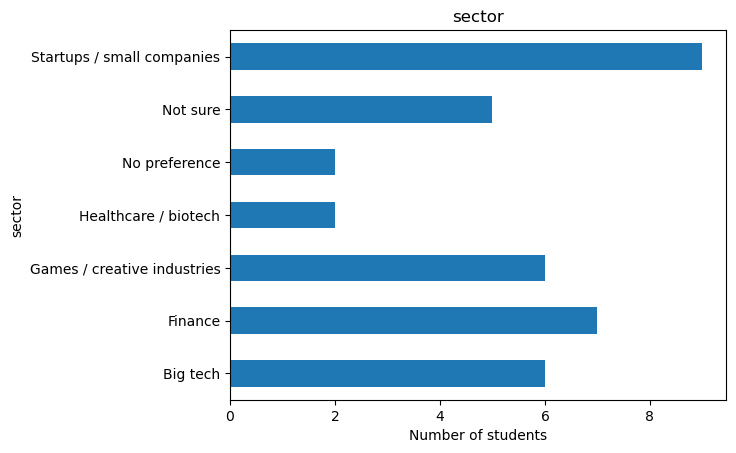

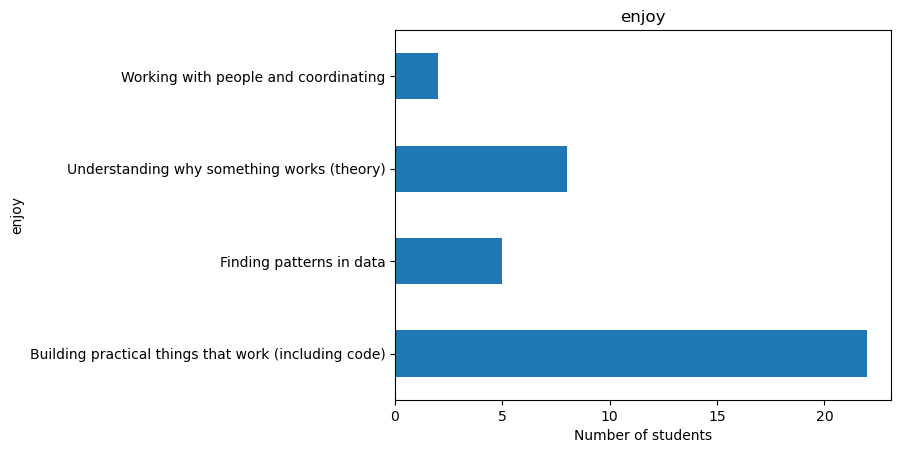

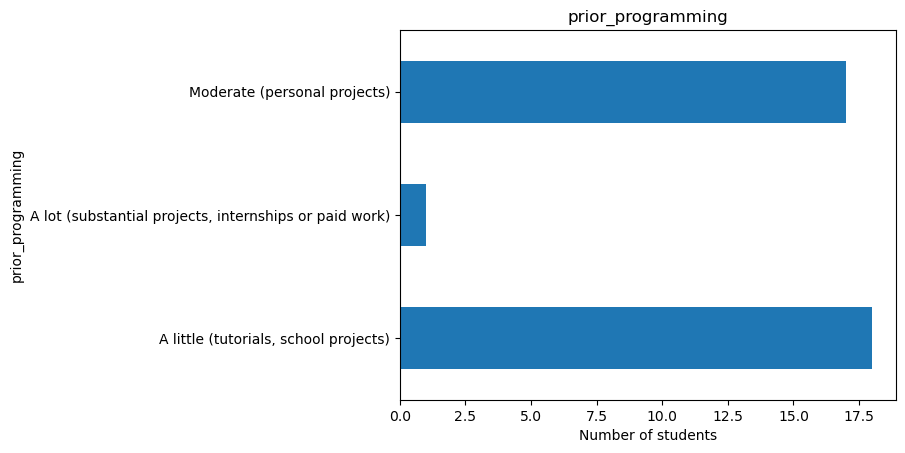

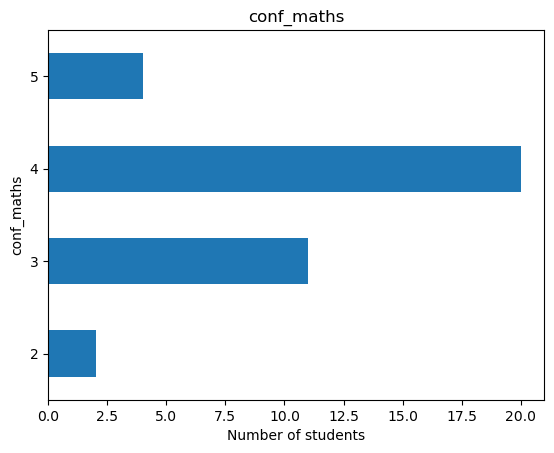

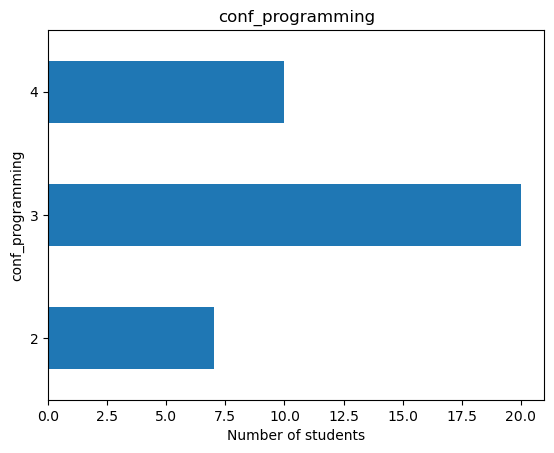

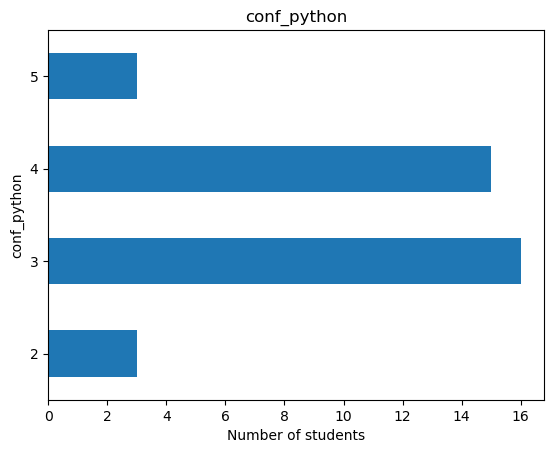

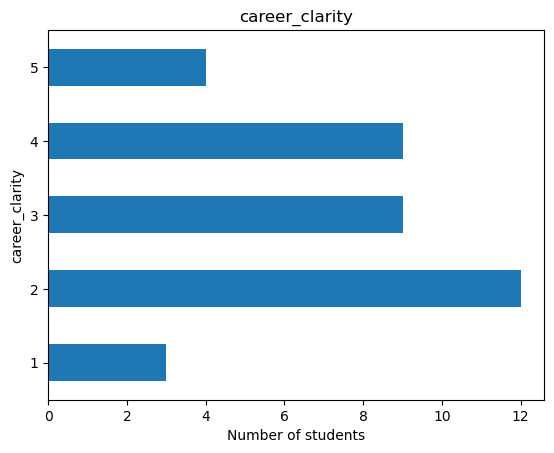

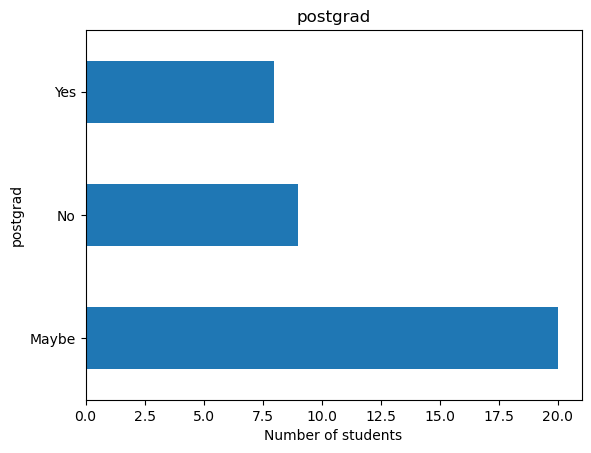

In [25]:
import matplotlib.pyplot as plt

# Columns we don't want to graph
exclude = ["id", "code", "comments"]

for column in real_csv.columns:

    if column not in exclude:

        counts = real_csv.groupby(column).size()

        counts.plot(kind="barh")

        plt.title(column)
        plt.xlabel("Number of students")
        plt.ylabel(column)

        plt.show()

Text(0, 0.5, 'A-level subject')

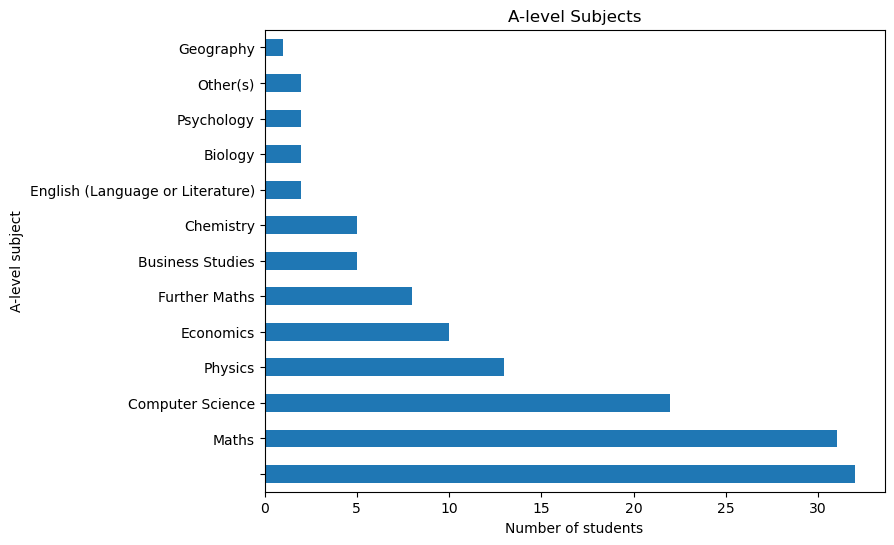

In [30]:
subject_counts = (
    real_csv["alevel_subjects"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

subject_counts.plot(kind="barh", figsize=(8, 6))
plt.title("A-level Subjects")
plt.xlabel("Number of students")
plt.ylabel("A-level subject")